Install Libraries

# Corporate AI Strategy Advisor

## Phase 1: Environment Setup

This notebook performs:

1. Dataset Loading
2. Data Cleaning
3. Data Validation
4. Exploratory Data Analysis
5. ROI Generation

Dataset:
Corporate AI Adoption Dataset (200K Rows)

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost catboost shap joblib openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

import warnings

warnings.filterwarnings("ignore")

Upload Dataset

In [3]:
from google.colab import files

uploaded = files.upload()

Saving corporate_ai_adoption_dataset.csv to corporate_ai_adoption_dataset.csv


Load Dataset

In [3]:
df = pd.read_csv("corporate_ai_adoption_dataset.csv")

Dataset Shape

In [4]:
print("Rows:",df.shape[0])

print("Columns:",df.shape[1])

Rows: 200000
Columns: 13


Column Names

In [5]:
df.columns

Index(['company_id', 'industry', 'country', 'year', 'ai_adoption_level',
       'ai_investment_usd', 'automation_rate', 'cost_savings',
       'revenue_impact', 'productivity_gain', 'employee_ai_training_hours',
       'ai_maturity_score', 'deployment_count'],
      dtype='object')

Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   company_id                  200000 non-null  object 
 1   industry                    200000 non-null  object 
 2   country                     200000 non-null  object 
 3   year                        200000 non-null  int64  
 4   ai_adoption_level           200000 non-null  float64
 5   ai_investment_usd           200000 non-null  int64  
 6   automation_rate             200000 non-null  float64
 7   cost_savings                200000 non-null  int64  
 8   revenue_impact              200000 non-null  int64  
 9   productivity_gain           200000 non-null  float64
 10  employee_ai_training_hours  200000 non-null  float64
 11  ai_maturity_score           200000 non-null  float64
 12  deployment_count            200000 non-null  int64  
dtypes: float64(5),

Missing Values

In [7]:
missing = df.isnull().sum()

missing

,0
company_id,0
industry,0
country,0
year,0
ai_adoption_level,0
ai_investment_usd,0
automation_rate,0
cost_savings,0
revenue_impact,0
productivity_gain,0


Missing Value Percentage

In [8]:
missing_percent = (

    df.isnull().sum()

    /

    len(df)

) * 100

missing_percent

,0
company_id,0.0
industry,0.0
country,0.0
year,0.0
ai_adoption_level,0.0
ai_investment_usd,0.0
automation_rate,0.0
cost_savings,0.0
revenue_impact,0.0
productivity_gain,0.0


Duplicate Rows

In [9]:
duplicates = df.duplicated().sum()

print(
    "Duplicate Rows:",
    duplicates
)

Duplicate Rows: 0


Remove Duplicates

In [10]:
df.drop_duplicates(
    inplace=True
)

print(df.shape)

(200000, 13)


Statistical Summary

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,200000.0,2.024991e+03,6.051632e+00,2015.00,2.020000e+03,2.025000e+03,2.030000e+03,2.035000e+03
ai_adoption_level,200000.0,5.277742e-01,2.564696e-01,0.01,3.344000e-01,5.286000e-01,7.250000e-01,1.000000e+00
ai_investment_usd,200000.0,4.870558e+06,3.679704e+06,47888.00,2.221252e+06,3.991640e+06,6.517931e+06,5.417034e+07
automation_rate,200000.0,4.367226e-01,2.170307e-01,0.00,2.735000e-01,4.281500e-01,5.920000e-01,9.500000e-01
cost_savings,200000.0,2.128918e+06,2.415689e+06,4649.00,5.993548e+05,1.354826e+06,2.745080e+06,4.433124e+07
revenue_impact,200000.0,2.591989e+06,3.972751e+06,-14376756.00,5.339805e+05,1.408779e+06,3.132148e+06,1.294787e+08
productivity_gain,200000.0,3.952970e-01,1.956234e-01,-0.05,2.493000e-01,3.926000e-01,5.393000e-01,9.403000e-01
employee_ai_training_hours,200000.0,7.675533e+01,4.004632e+01,1.00,4.650000e+01,7.540000e+01,1.059000e+02,1.979000e+02
ai_maturity_score,200000.0,6.271801e+00,1.930643e+00,1.00,4.730000e+00,6.280000e+00,7.830000e+00,1.000000e+01
deployment_count,200000.0,2.633735e+01,1.185326e+01,3.00,1.600000e+01,2.500000e+01,3.600000e+01,5.800000e+01


Check Unique Industries

In [12]:
df["industry"].unique()

array(['Financial Services', 'Agriculture', 'Energy', 'Retail',
       'Technology', 'Manufacturing', 'Telecom', 'Education', 'Logistics',
       'Healthcare'], dtype=object)

Industry Count

In [13]:
df["industry"].value_counts()

,count
industry,
Technology,35994
Manufacturing,29884
Financial Services,27927
Healthcare,24026
Retail,20048
Logistics,16021
Telecom,14128
Energy,14080
Agriculture,9934


Country Count

In [14]:
df["country"].value_counts()

,count
country,
United States,50080
China,35906
Germany,16040
Japan,14125
United Kingdom,13989
India,13911
Canada,10114
France,9896
South Korea,8033


Remove company_id

In [15]:
df.drop(
    columns=["company_id"],
    errors="ignore",
    inplace=True
)

Verify Dataset

In [16]:
df.shape

(200000, 12)

Histogram

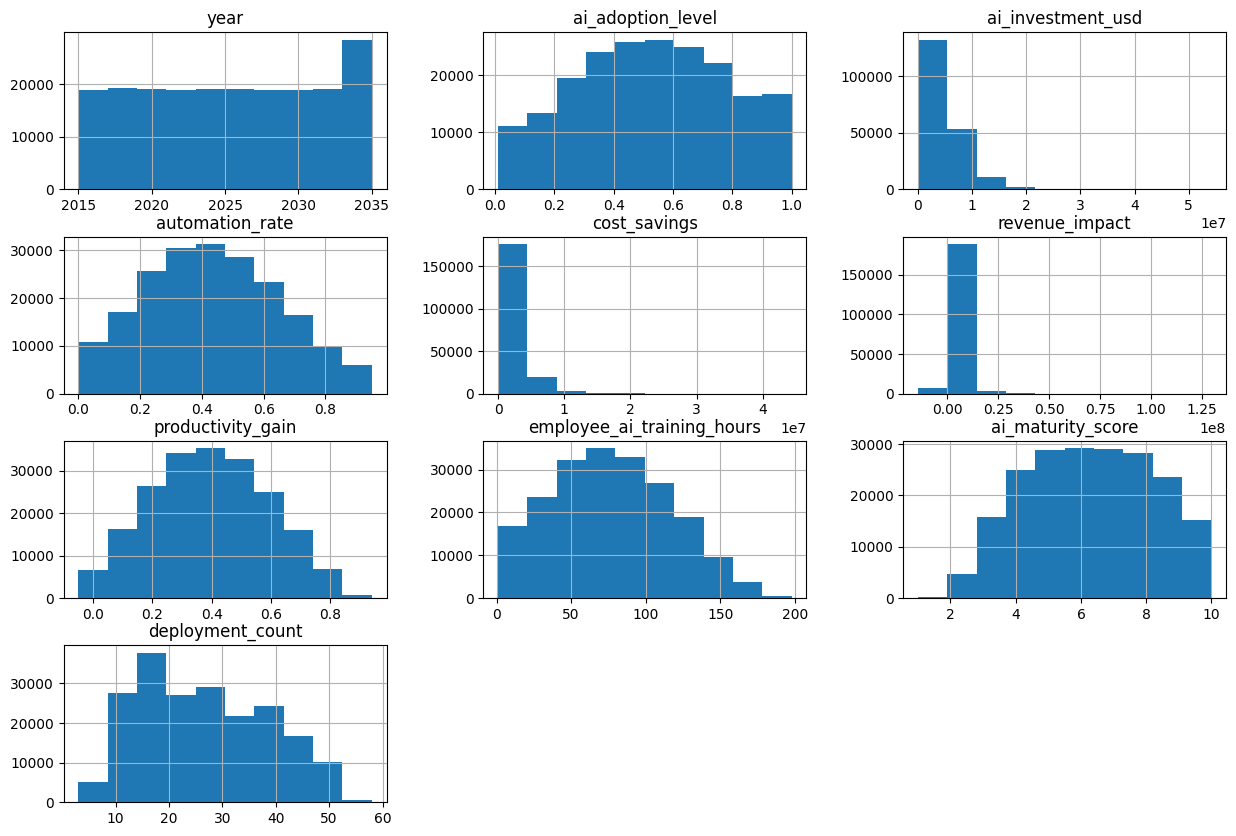

In [17]:
df.hist(
    figsize=(15,10)
)

plt.show()

AI Investment Distribution

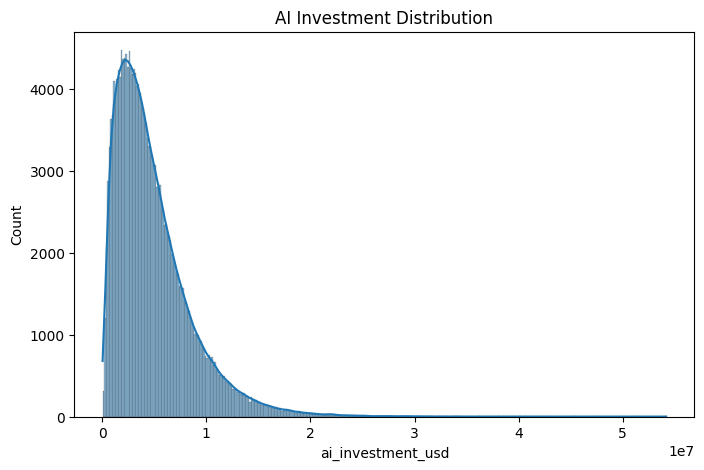

In [18]:
plt.figure(
    figsize=(8,5)
)

sns.histplot(
    df["ai_investment_usd"],
    kde=True
)

plt.title(
    "AI Investment Distribution"
)

plt.show()

Automation Rate Distribution

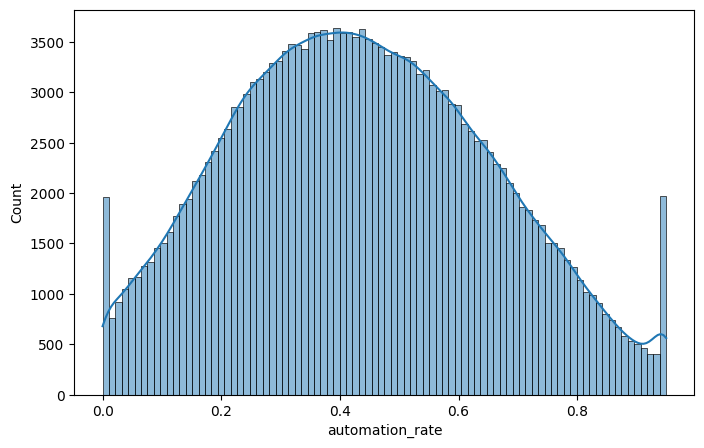

In [19]:
plt.figure(
    figsize=(8,5)
)

sns.histplot(
    df["automation_rate"],
    kde=True
)

plt.show()

Productivity Distribution

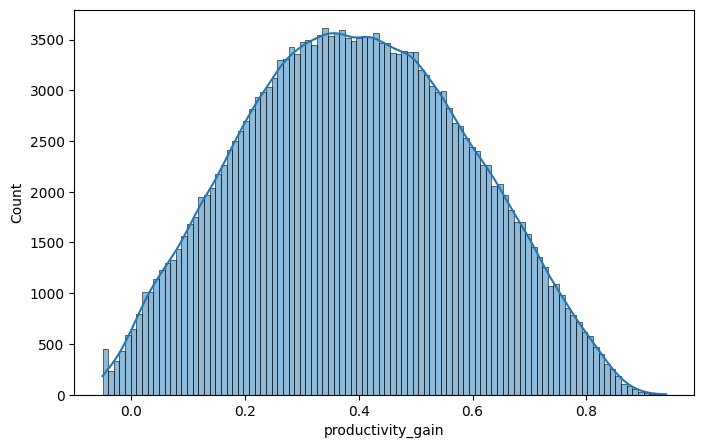

In [20]:
plt.figure(
    figsize=(8,5)
)

sns.histplot(
    df["productivity_gain"],
    kde=True
)

plt.show()

Correlation Matrix

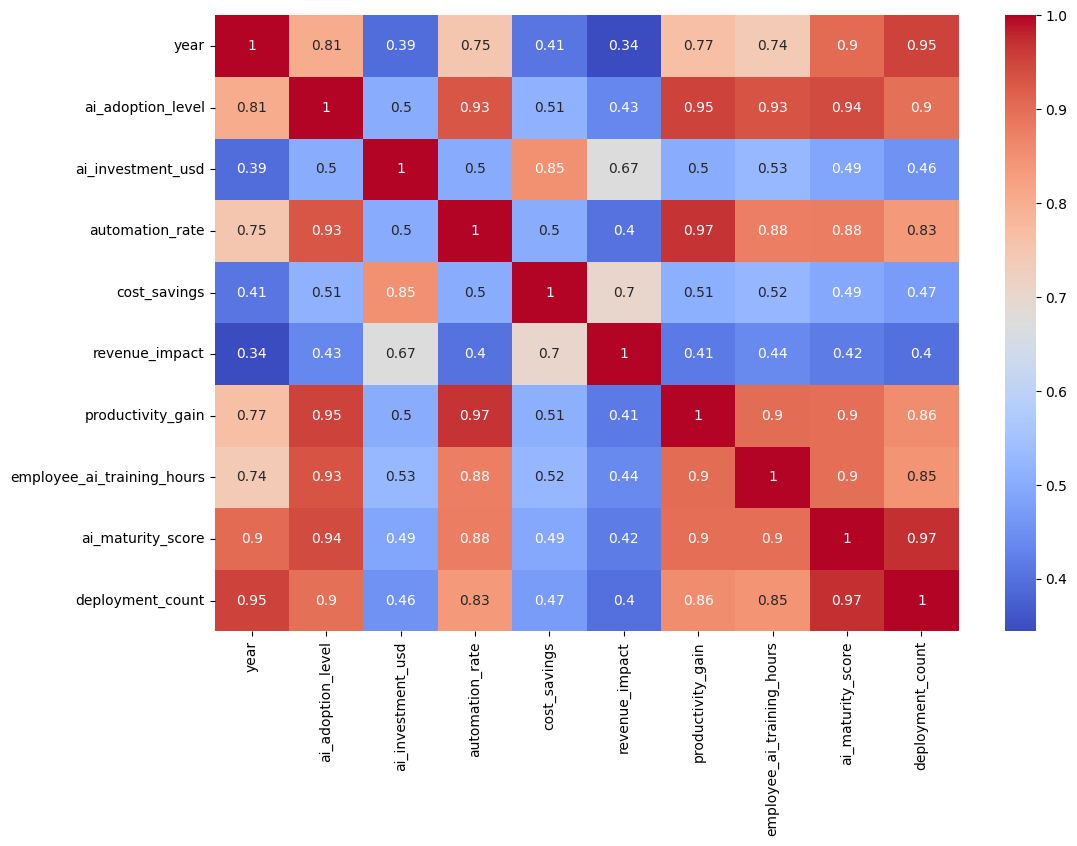

In [21]:
plt.figure(
    figsize=(12,8)
)

sns.heatmap(

    df.corr(
        numeric_only=True
    ),

    annot=True,

    cmap="coolwarm"

)

plt.show()

Industry Wise Cost Savings

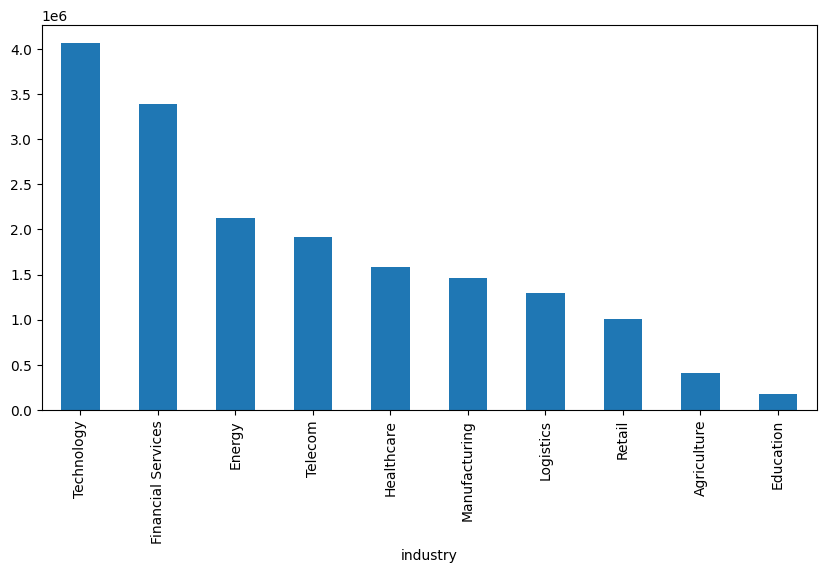

In [22]:
industry_cost = (

    df.groupby(
        "industry"
    )["cost_savings"]

    .mean()

    .sort_values(
        ascending=False
    )

)

industry_cost.plot(
    kind="bar",
    figsize=(10,5)
)

plt.show()

Industry Wise Revenue Impact

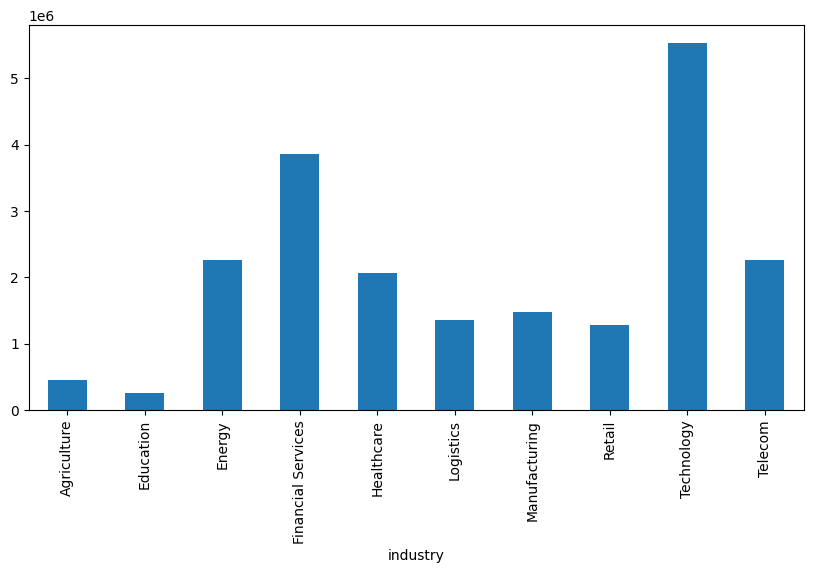

In [23]:
industry_revenue = (

    df.groupby(
        "industry"
    )["revenue_impact"]

    .mean()

)

industry_revenue.plot(
    kind="bar",
    figsize=(10,5)
)

plt.show()

Industry Wise Productivity

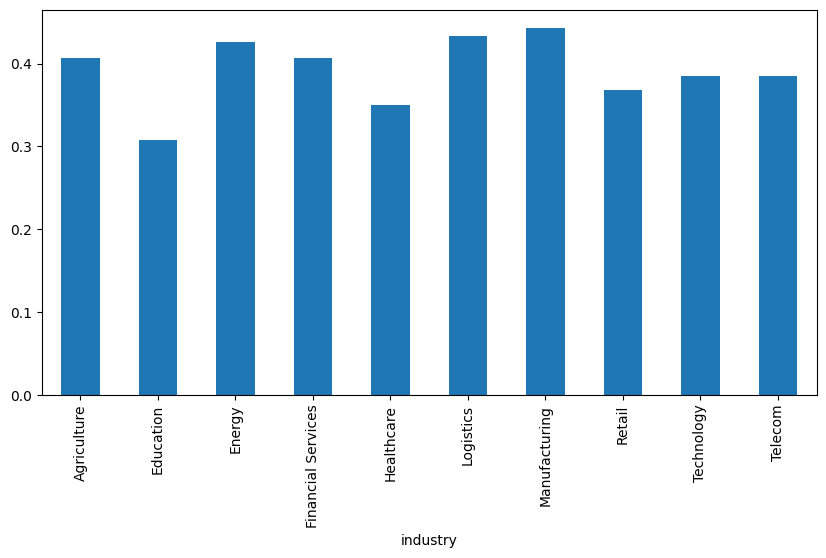

In [24]:
industry_productivity = (

    df.groupby(
        "industry"
    )["productivity_gain"]

    .mean()

)

industry_productivity.plot(
    kind="bar",
    figsize=(10,5)
)

plt.show()

ROI CREATION

In [25]:
df["roi"] = (

    (

        df["revenue_impact"]

        +

        df["cost_savings"]

        -

        df["ai_investment_usd"]

    )

    /

    df["ai_investment_usd"]

) * 100

Verify ROI

In [26]:
df["roi"].describe()

,roi
count,200000.000000
mean,-18.903874
std,49.473987
min,-234.754418
25%,-49.941936
50%,-28.516594
75%,-0.818782
max,850.676487


ROI Distribution

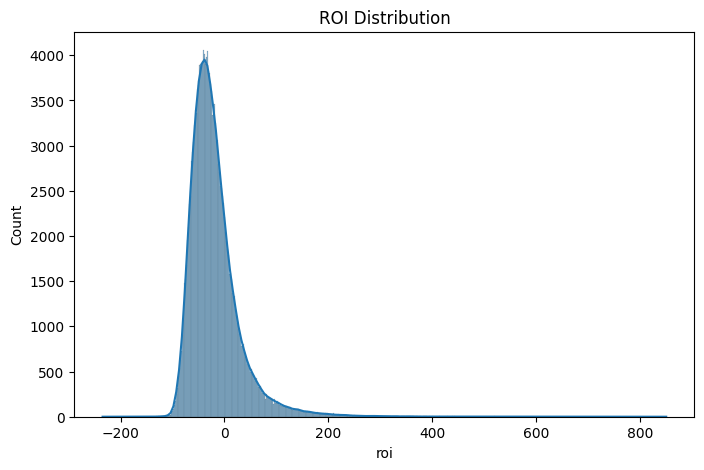

In [27]:
plt.figure(
    figsize=(8,5)
)

sns.histplot(
    df["roi"],
    kde=True
)

plt.title(
    "ROI Distribution"
)

plt.show()

Save Clean Dataset

In [28]:
df.to_csv(

    "cleaned_dataset.csv",

    index=False

)

print(
    "Dataset Saved Successfully"
)

Dataset Saved Successfully


# Corporate AI Strategy Advisor

## Part 2

Feature Engineering

Data Preprocessing

Model Training

Model Evaluation

Model Comparison

Import Libraries

In [30]:
!pip install catboost

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from catboost import CatBoostRegressor

import warnings

warnings.filterwarnings("ignore")

FEATURE ENGINEERING

Dataset Shape

In [30]:
print(df.shape)

(200000, 13)


Encode Industry

In [31]:
industry_encoder = LabelEncoder()

df["industry"] = (

    industry_encoder.fit_transform(

        df["industry"]

    )

)

Encode Country

In [32]:
country_encoder = LabelEncoder()

df["country"] = (

    country_encoder.fit_transform(

        df["country"]

    )

)

Encode AI Adoption Level

In [33]:
adoption_encoder = LabelEncoder()

df["ai_adoption_level"] = (

    adoption_encoder.fit_transform(

        df["ai_adoption_level"]

    )

)

Verify Encoded Dataset

In [34]:
df.head()

,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count,roi
0,3,3,2029,4884,11747237,0.4119,3519354,2751513,0.3924,76.8,6.37,29,-46.618367
1,0,5,2032,5110,1267219,0.4580,295244,304776,0.4639,83.2,7.19,37,-52.650647
2,2,14,2024,6044,8168951,0.5821,2472329,5170304,0.4953,123.1,6.72,26,-6.442908
3,7,5,2021,4298,1234261,0.2880,512061,-233448,0.3078,63.1,5.68,21,-77.426736
4,8,14,2024,1815,5000645,0.1906,2122064,2110644,0.1910,29.6,4.33,16,-15.356759


PREPROCESSING

In [35]:
X = df.drop(

    columns=[

        "cost_savings",

        "revenue_impact",

        "productivity_gain",

        "roi"

    ]

)

Verify Features

In [36]:
X.head()

,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,employee_ai_training_hours,ai_maturity_score,deployment_count
0,3,3,2029,4884,11747237,0.4119,76.8,6.37,29
1,0,5,2032,5110,1267219,0.4580,83.2,7.19,37
2,2,14,2024,6044,8168951,0.5821,123.1,6.72,26
3,7,5,2021,4298,1234261,0.2880,63.1,5.68,21
4,8,14,2024,1815,5000645,0.1906,29.6,4.33,16


MODEL TRAINING

TARGET 1
COST SAVINGS

In [37]:
df = df.sample(100000, random_state=42)

In [38]:
y_cost = df["cost_savings"]

In [39]:
from sklearn.preprocessing import LabelEncoder

industry_encoder = LabelEncoder()

df["industry"] = industry_encoder.fit_transform(
    df["industry"]
)

In [40]:
country_encoder = LabelEncoder()

df["country"] = country_encoder.fit_transform(
    df["country"]
)

In [41]:
adoption_encoder = LabelEncoder()

df["ai_adoption_level"] = adoption_encoder.fit_transform(
    df["ai_adoption_level"]
)

In [42]:
print(df.dtypes)

industry                        int64
country                         int64
year                            int64
ai_adoption_level               int64
ai_investment_usd               int64
automation_rate               float64
cost_savings                    int64
revenue_impact                  int64
productivity_gain             float64
employee_ai_training_hours    float64
ai_maturity_score             float64
deployment_count                int64
roi                           float64
dtype: object


In [43]:
X = df.drop(
    columns=[
        "cost_savings",
        "revenue_impact",
        "productivity_gain",
        "roi"
    ]
)

In [44]:
y_cost = df["cost_savings"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cost,
    test_size=0.2,
    random_state=42
)

In [54]:
rf_cost.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, random_state=42)

Train Test Split

In [46]:
df = df.sample(100000, random_state=42)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cost,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80000, 9)
X_test shape: (20000, 9)
y_train shape: (80000,)
y_test shape: (20000,)


RANDOM FOREST

In [48]:
rf_cost = RandomForestRegressor(

    n_estimators=200,

    random_state=42

)

rf_cost.fit(

    X_train,

    y_train

)

RandomForestRegressor(n_estimators=200, random_state=42)

XGBOOST

In [49]:
xgb_cost = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42

)

xgb_cost.fit(

    X_train,

    y_train

)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

CATBOOST

In [50]:
cat_cost = CatBoostRegressor(

    iterations=300,

    learning_rate=0.05,

    depth=6,

    verbose=0

)

cat_cost.fit(

    X_train,

    y_train

)

CatBoostRegressor(depth=6, iterations=300, learning_rate=0.05, loss_function='RMSE', verbose=0)

MODEL EVALUATION

Evaluation Function

In [52]:
def evaluate_model(

    model,

    X_test,

    y_test

):

    pred = model.predict(

        X_test

    )

    mae = mean_absolute_error(

        y_test,

        pred

    )

    mse = mean_squared_error(

        y_test,

        pred

    )

    rmse = np.sqrt(

        mse

    )

    r2 = r2_score(

        y_test,

        pred

    )

    return [

        mae,

        mse,

        rmse,

        r2

    ]

Compare Models

In [53]:
results_cost = pd.DataFrame({

    "RandomForest":

    evaluate_model(

        rf_cost,

        X_test,

        y_test

    ),

    "XGBoost":

    evaluate_model(

        xgb_cost,

        X_test,

        y_test

    ),

    "CatBoost":

    evaluate_model(

        cat_cost,

        X_test,

        y_test

    )

},

index=[

    "MAE",

    "MSE",

    "RMSE",

    "R2"

]

)

results_cost

,RandomForest,XGBoost,CatBoost
MAE,5.439432e+05,5.254878e+05,5.232873e+05
MSE,1.028059e+12,9.780382e+11,9.527559e+11
RMSE,1.013932e+06,9.889581e+05,9.760921e+05
R2,8.297054e-01,8.379912e-01,8.421791e-01


TARGET 2 Revenue Impact

In [54]:
y_revenue = df["revenue_impact"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_revenue,
    test_size=0.2,
    random_state=42
)

Random Forest

In [56]:
rf_revenue = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_revenue.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, random_state=42)

XGBoost

In [57]:
xgb_revenue = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_revenue.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

CatBoost

In [58]:
cat_revenue = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

cat_revenue.fit(
    X_train,
    y_train
)

CatBoostRegressor(depth=6, iterations=300, learning_rate=0.05, loss_function='RMSE', verbose=0)

Evaluation

In [59]:
results_revenue = pd.DataFrame({

    "RandomForest":
    evaluate_model(
        rf_revenue,
        X_test,
        y_test
    ),

    "XGBoost":
    evaluate_model(
        xgb_revenue,
        X_test,
        y_test
    ),

    "CatBoost":
    evaluate_model(
        cat_revenue,
        X_test,
        y_test
    )

},

index=[
    "MAE",
    "MSE",
    "RMSE",
    "R2"
])

results_revenue

,RandomForest,XGBoost,CatBoost
MAE,2.475984e+06,2.333531e+06,2.315912e+06
MSE,1.695670e+13,1.660571e+13,1.632653e+13
RMSE,4.117852e+06,4.075010e+06,4.040610e+06
R2,-4.026315e-02,-1.873016e-02,-1.602957e-03


TARGET 3 — PRODUCTIVITY GAIN

In [67]:
y_productivity = df["productivity_gain"]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_productivity,
    test_size=0.2,
    random_state=42
)

Random Forest

In [69]:
rf_productivity = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_productivity.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, random_state=42)

XGBoost

In [70]:
xgb_productivity = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_productivity.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

CatBoost

In [71]:
cat_productivity = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

cat_productivity.fit(
    X_train,
    y_train
)

CatBoostRegressor(depth=6, iterations=300, learning_rate=0.05, loss_function='RMSE', verbose=0)

Evaluation

In [72]:
results_productivity = pd.DataFrame({

    "RandomForest":
    evaluate_model(
        rf_productivity,
        X_test,
        y_test
    ),

    "XGBoost":
    evaluate_model(
        xgb_productivity,
        X_test,
        y_test
    ),

    "CatBoost":
    evaluate_model(
        cat_productivity,
        X_test,
        y_test
    )

},

index=[
    "MAE",
    "MSE",
    "RMSE",
    "R2"
])

results_productivity

,RandomForest,XGBoost,CatBoost
MAE,0.163374,0.162435,0.161836
MSE,0.039188,0.038466,0.038166
RMSE,0.197960,0.196128,0.195361
R2,-0.029610,-0.010639,-0.002757


TARGET 4 — ROI

In [60]:
y_roi = df["roi"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_roi,
    test_size=0.2,
    random_state=42
)

Random Forest

In [62]:
rf_roi = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_roi.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, random_state=42)

XGBoost

In [63]:
xgb_roi = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_roi.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

CatBoost

In [64]:
cat_roi = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

cat_roi.fit(
    X_train,
    y_train
)

CatBoostRegressor(depth=6, iterations=300, learning_rate=0.05, loss_function='RMSE', verbose=0)

Evaluation

In [65]:
results_roi = pd.DataFrame({

    "RandomForest":
    evaluate_model(
        rf_roi,
        X_test,
        y_test
    ),

    "XGBoost":
    evaluate_model(
        xgb_roi,
        X_test,
        y_test
    ),

    "CatBoost":
    evaluate_model(
        cat_roi,
        X_test,
        y_test
    )

},

index=[
    "MAE",
    "MSE",
    "RMSE",
    "R2"
])

results_roi

,RandomForest,XGBoost,CatBoost
MAE,35.277370,34.300993,34.150679
MSE,2531.966991,2470.718144,2455.594841
RMSE,50.318655,49.706319,49.553959
R2,-0.032885,-0.007899,-0.001730


In [73]:
print("COST SAVINGS")
display(results_cost)

print("REVENUE IMPACT")
display(results_revenue)

print("PRODUCTIVITY GAIN")
display(results_productivity)

print("ROI")
display(results_roi)

COST SAVINGS


,RandomForest,XGBoost,CatBoost
MAE,5.439432e+05,5.254878e+05,5.232873e+05
MSE,1.028059e+12,9.780382e+11,9.527559e+11
RMSE,1.013932e+06,9.889581e+05,9.760921e+05
R2,8.297054e-01,8.379912e-01,8.421791e-01


REVENUE IMPACT


,RandomForest,XGBoost,CatBoost
MAE,2.475984e+06,2.333531e+06,2.315912e+06
MSE,1.695670e+13,1.660571e+13,1.632653e+13
RMSE,4.117852e+06,4.075010e+06,4.040610e+06
R2,-4.026315e-02,-1.873016e-02,-1.602957e-03


PRODUCTIVITY GAIN


,RandomForest,XGBoost,CatBoost
MAE,0.163374,0.162435,0.161836
MSE,0.039188,0.038466,0.038166
RMSE,0.197960,0.196128,0.195361
R2,-0.029610,-0.010639,-0.002757


ROI


,RandomForest,XGBoost,CatBoost
MAE,35.277370,34.300993,34.150679
MSE,2531.966991,2470.718144,2455.594841
RMSE,50.318655,49.706319,49.553959
R2,-0.032885,-0.007899,-0.001730


SHAP EXPLAINABILITY

Install SHAP

In [74]:
!pip install shap

Imports

In [75]:
import shap
import matplotlib.pyplot as plt

Since CatBoost won:

In [76]:
best_model = cat_cost

Create Explainer

In [77]:
explainer = shap.TreeExplainer(
    best_model
)

Generate SHAP Values

In [78]:
shap_values = explainer.shap_values(
    X_test
)

Global Feature Importance

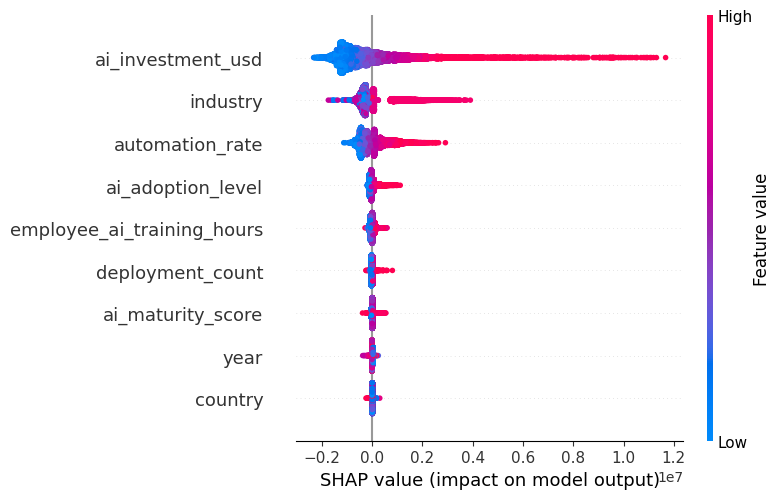

In [79]:
shap.summary_plot(
    shap_values,
    X_test
)

Bar Plot

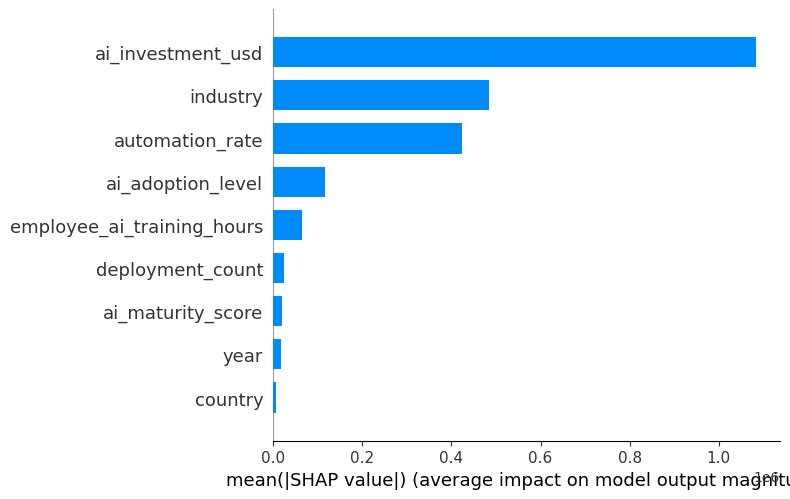

In [80]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

INDUSTRY BENCHMARKING

Industry Average

In [81]:
industry_avg = df.groupby(
    "industry"
).agg({

    "cost_savings":"mean",

    "revenue_impact":"mean",

    "productivity_gain":"mean",

    "roi":"mean"

})

industry_avg

,cost_savings,revenue_impact,productivity_gain,roi
industry,,,,
0,4.084107e+05,4.454694e+05,0.410707,-42.071719
1,1.774966e+05,2.544930e+05,0.303857,-52.537452
2,2.122243e+06,2.242969e+06,0.426893,-32.615064
3,3.398584e+06,3.876742e+06,0.406579,-21.595215
4,1.579401e+06,2.062690e+06,0.350562,-34.137896
5,1.302526e+06,1.360651e+06,0.434236,-27.862027
6,1.463413e+06,1.474466e+06,0.442783,-35.752482
7,1.006284e+06,1.290183e+06,0.367208,-16.799378
8,4.064031e+06,5.549892e+06,0.384084,31.404127


Top 25%

In [82]:
top25 = df.groupby(
    "industry"
).agg({

    "roi":lambda x: x.quantile(0.75)

})

top25

,roi
industry,
0,-27.127505
1,-40.427334
2,-14.518842
3,-1.008085
4,-17.427731
5,-8.746906
6,-18.154955
7,5.156777
8,65.040198


Top 10%

In [83]:
top10 = df.groupby(
    "industry"
).agg({

    "roi":lambda x: x.quantile(0.90)

})

top10

,roi
industry,
0,-10.582102
1,-26.514112
2,5.449210
3,25.016417
4,3.312191
5,13.471936
6,0.793686
7,33.303709
8,123.932307


Save Benchmark Files

In [84]:
industry_avg.to_csv(
    "industry_avg.csv"
)

top25.to_csv(
    "top25_benchmark.csv"
)

top10.to_csv(
    "top10_benchmark.csv"
)

SUCCESS PROBABILITY ENGINE

Create Function

In [85]:
def success_probability(
    maturity_score,
    automation_rate,
    training_hours
):

    score = (

        maturity_score * 0.4

        +

        automation_rate * 100 * 0.3

        +

        training_hours * 0.3

    )

    return min(
        round(score,2),
        100
    )

Example

In [86]:
success_probability(
    maturity_score=80,
    automation_rate=0.75,
    training_hours=60
)

72.5

Apply To Dataset

In [87]:
df["success_probability"] = df.apply(

    lambda row:

    success_probability(

        row["ai_maturity_score"],

        row["automation_rate"],

        row["employee_ai_training_hours"]

    ),

    axis=1

)

View Results

In [88]:
df[[
    "success_probability"
]].head()

,success_probability
135757,24.83
153617,46.00
61220,43.76
48640,31.70
22495,52.10


RECOMMENDATION ENGINE

Recommendation Function

In [89]:
def generate_recommendations(

    automation,

    training,

    maturity

):

    recommendations = []

    if automation < 0.40:

        recommendations.append(

            "Increase automation initiatives"

        )

    if training < 50:

        recommendations.append(

            "Increase employee AI training"

        )

    if maturity < 50:

        recommendations.append(

            "Improve AI maturity strategy"

        )

    if len(recommendations) == 0:

        recommendations.append(

            "AI strategy is performing well"

        )

    return recommendations

Test

In [90]:
generate_recommendations(

    automation=0.25,

    training=30,

    maturity=40

)

['Increase automation initiatives',
 'Increase employee AI training',
 'Improve AI maturity strategy']

Apply To Dataset

In [91]:
df["recommendations"] = df.apply(

    lambda row:

    str(

        generate_recommendations(

            row["automation_rate"],

            row["employee_ai_training_hours"],

            row["ai_maturity_score"]

        )

    ),

    axis=1

)

Verify

In [92]:
df[[
    "success_probability",
    "recommendations"
]].head()

,success_probability,recommendations
135757,24.83,"['Increase automation initiatives', 'Improve A..."
153617,46.00,['Improve AI maturity strategy']
61220,43.76,['Improve AI maturity strategy']
48640,31.70,"['Increase automation initiatives', 'Improve A..."
22495,52.10,['Improve AI maturity strategy']


MODEL EXPORT

In [93]:
!pip install joblib

Import

In [94]:
import joblib

Save Cost Savings Model

In [95]:
joblib.dump(
    cat_cost,
    "cost_savings_model.pkl"
)

['cost_savings_model.pkl']

Save Revenue Impact Model

In [96]:
joblib.dump(
    cat_revenue,
    "revenue_impact_model.pkl"
)

['revenue_impact_model.pkl']

Save Productivity Gain Model

In [97]:
joblib.dump(
    cat_productivity,
    "productivity_gain_model.pkl"
)

['productivity_gain_model.pkl']

Save ROI Model

In [98]:
joblib.dump(
    cat_roi,
    "roi_model.pkl"
)

['roi_model.pkl']

In [99]:
import os

print(os.listdir())

['.config', 'top10_benchmark.csv', 'roi_model.pkl', 'corporate_ai_adoption_dataset.csv', 'productivity_gain_model.pkl', 'top25_benchmark.csv', 'revenue_impact_model.pkl', 'catboost_info', 'industry_avg.csv', 'cost_savings_model.pkl', 'cleaned_dataset.csv', 'sample_data']


In [103]:
from google.colab import files

files.download(
    "roi_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>